# Reduced equations (steady-state solution)

Let's integrate to find the steady-state solution for the reduced equations:

$$ 0 = \frac{\partial \mathcal{W}}{\partial t} = \frac{1}{\Sigma \Omega R^3 } \frac{\partial \mathcal{G}}{\partial R} - \left(\frac{\Omega_z^2 - \Omega^2}{\Omega^2} \right) \frac{i\Omega}2 \mathcal{W}.$$
$$ 0 = \frac{\partial \mathcal{G}}{\partial t} = \frac{\Sigma H^2 \Omega^3 R^3}4 \frac{\partial \mathcal{W}}{\partial R}  - \left( \frac{\kappa^2 - \Omega^2}{\Omega^2} \right) \frac{i\Omega}2 \mathcal{G} - \alpha \Omega \mathcal{G}. $$

Our goal is to (numerically) derive the critical bending mass as a function of gap depth $\Sigma_\text{gap}/\Sigma_0$. This is what Jeremy shows in Figure 4 of his paper draft.

In [65]:
eps = .1 # softening term
cs = .1 # sound speed (also, scale height at R=a)
alpha = 0 # viscosity parameter
Delta_g = .5 # half-width of gap
a = 1 # radial coordinate of planet
#Rout = 200 # radial coordinate of disk's outer edge

use_Jeremys_profile = True # gapped density profile with Sigma ~ R^(-3/2)
use_gap = False # turns on/off gap in density profile

In [16]:
import numpy as np
import pandas as pd
import tables
import time
import math
#import scipy.differentiate
import scipy.integrate as integ
import scipy.interpolate as interp

import matplotlib.pyplot as plt

## Numerical derivatives

In [17]:
def derivative(f, x):
    '''
    Returns first derivative of f(x) with respect to the domain x.

    '''
    
    # return scipy.differentiate.derivative(f, x)

    derivs = np.zeros(shape=f.shape)

    # handle boundaries
    derivs[0] = (f[1] - f[0]) / (x[1] - x[0])
    derivs[-1] = (f[-1] - f[-2]) / (x[-1] - x[-2])

    # central difference method
    for i in range(1, len(x)-1):
        derivs[i] = (f[i+1] - f[i-1]) / (x[i+1] - x[i-1])

    return derivs

# Disk information

Normalizations:
- $R_0 = 1$
- $\Omega_{K,0} = 1$ (so $GM = 1$)
- $\Sigma_0 = 1$

## Density profile

In [37]:
def Sigma(R, use_gap, K=1):
    '''
    Returns the disk's background surface density profile
    at a specific radius R.
    
    If use_gap is False, do not include a gap in the profile.
    K is the gap depth, representing the ratio of the "background"
    density to the density in the gap. K=1 means no gap.
    
    '''
    
    # K, R_a, R_b, D_a, D_b = 19, 0.5, 1.5, 0.1, 0.2
    # fgaps = f_gap(Rs, K, R_a, R_b, D_a, D_b, use_gap)
    # Sigma0 = 1
    # return Sigma0 * Rs**(-3/2) / fgaps

    ## upside-down top hat profile
    R_a = a - Delta_g
    R_b = a + Delta_g
    if (R > R_a) and (R < R_b):
        return (1/K) * R**(-3/2)
    else:
        return 1 * R**(-3/2) 

def f_gap(Rs, K, R_a, R_b, D_a, D_b, use_gap):
    '''
    Function that "shapes" the disk gap profile. Used in `sigma` function. 
    R_a and R_b are the locations of the inner and outer gap edges,
    D_a and D_b are the steepness of the edges, and K determines the
    depth of the gap.
    If use_gap is False, return 1 (i.e., no disk gap).
    
    '''

    if use_gap:
        return 1 + (K-1)/2 * \
            (np.tanh((Rs - R_a)/D_a) - np.tanh((Rs - R_b)/D_b))
    else:
        return 1

Sigma = np.vectorize(Sigma)

## Keplerian orbital frequency

Scale height, which depends on $\Omega$, is defined in the "Planet information" section below.

In [19]:
def OmegaK(Rs):
    '''
    Returns the Keplerian orbital frequency profile.
    Omega_K = sqrt(G*M_star / R^3)

    '''
    OmegaK_0 = 1 # Omega_K at R=R_0
    return OmegaK_0 * Rs**(-3/2)

# Planet information

## Laplace coefficients

In [20]:
def laplace_coeff_integrand(phi, x, j, s, eps):
    '''
    
    This function represents the integrand of the Laplace coefficient formula
    (Eq. 6.67 of Murray & Dermott). The result is used in the laplace_coeff function.
    
    PARAMETERS
    ----------
    phi: the variable that we integrate over (eg, an angle)
    x: the variable that isn't integrated over; argument of Laplace coeff function
    j, s: See Eq. 6.67 of Murray & Dermott or Eq. 21 in Lubow+Ogilvie.
    eps: gravitational softening term
    
    '''
    
    num = np.cos(j*phi) # numerator
    denom = (1 - 2 * x * np.cos(phi) + x**2 + eps**2) ** s
    
    return num / denom

def laplace_coeff(x, j, s, eps):
    '''
    
    Calculate the Laplace coefficient using Eq. 6.67 of Murray & Dermott.

    
    PARAMETERS
    ----------
    x: argument of the Laplace coefficient formula
    j, s: See Eq. 6.67 of Murray & Dermott or Eq. 21 in Lubow+Ogilvie.
    eps: gravitational softening term
    
    '''
    
    return 2 / np.pi * integ.quad(laplace_coeff_integrand, 0, np.pi, args=(x, j, s, eps))[0]

To speed things up, I'll interpolate the Laplace coefficients:

In [21]:
# interpolate Laplace coefficient function (~10x faster)
# large alpha limit
xs_temp = np.linspace(1+(1e-3 * eps), 110, 10000)
ys_temp = [laplace_coeff(x, j=0, s=3/2, eps=eps) for x in xs_temp]
b0_interp_large_alpha = interp.CubicSpline(xs_temp, ys_temp)

ys_temp = [laplace_coeff(x, j=1, s=3/2, eps=eps) for x in xs_temp]
b1_interp_large_alpha = interp.CubicSpline(xs_temp, ys_temp)

# small alpha limit
xs_temp = np.linspace(1e-3, 1-(1e-3 * eps), 1000)
ys_temp = [laplace_coeff(x, j=0, s=3/2, eps=eps) for x in xs_temp]
b0_interp_small_alpha = interp.CubicSpline(xs_temp, ys_temp)

ys_temp = [laplace_coeff(x, j=1, s=3/2, eps=eps) for x in xs_temp]
b1_interp_small_alpha = interp.CubicSpline(xs_temp, ys_temp)

And let's check that our approximated functions are accurate:

In [22]:
# correctness checks
print("Correctness check: for alpha >> 1, b^1_{3/2} ~ 3/alpha^4.")
x = 1 + 1e-2*eps
print(laplace_coeff(x, j=1, s=3/2, eps=eps))
#print(b1_approx(x,limit="large"))
print(b1_interp_large_alpha(x))

print("\nCorrectness check: for alpha >> 1, b^0_{3/2} ~ 2/alpha^3.")
x = 1+1e-2*eps
print(laplace_coeff(x, j=0, s=3/2, eps=eps))
#print(b0_approx(x,limit="large"))
print(b0_interp_large_alpha(x))

print("\nCorrectness check: for alpha << 1, b^1_{3/2} ~ 3*alpha.")
x = 1-1e-2*eps
print(laplace_coeff(x, j=1, s=3/2, eps=eps))
#print(b1_approx(x,limit="small"))
print(b1_interp_small_alpha(x))

print("\nCorrectness check: for alpha << 1, b^0_{3/2} ~ 2.")
x = 1-1e-2*eps
print(laplace_coeff(x, j=0, s=3/2, eps=eps))
#print(b0_approx(x,limit="small"))
print(b0_interp_small_alpha(x))


Correctness check: for alpha >> 1, b^1_{3/2} ~ 3/alpha^4.
62.77893239034101
62.7810871211246

Correctness check: for alpha >> 1, b^0_{3/2} ~ 2/alpha^3.
63.85218379852735
63.854341155276394

Correctness check: for alpha << 1, b^1_{3/2} ~ 3*alpha.
62.84029063296931
62.840290711639575

Correctness check: for alpha << 1, b^0_{3/2} ~ 2.
63.91644481121259
63.91644488997897


## Orbital, epicyclic, and radial frequencies

(I use Eqs. 25-27 in Lubow+Ogilvie 2000 for the star+planet potential, and I also include the contribution from the disk pressure.)

In [35]:
def Omega(Rs, Mp, a, cs, use_gap, K):
    '''
    Returns the disk's orbital frequency over a radial
    domain. 
    
    VARIABLES:
    ----------
    Rs is the radial domain.
    Mp is the ratio of the planet's mass to the star mass (using the normalization 
    GM_star = 1). For example, if we assume M_star = 1 M_sun, then a Jupiter-mass
    planet would have Mp = 0.001.
    a is the radius of the planet's orbit.
    use_gap toggles whether we include a gap in the density profile.
    K is the gap depth.

    '''

    # Omega^2 without an external potential
    Omegas_sq = OmegaK(Rs)**2
    Sigs = Sigma(Rs, use_gap, K)
    Hs = scaleHeight(Rs, cs)
    disk_term = (cs**2 / Rs) * derivative(Sigs/Hs, Rs) / (Sigs/Hs)
    # Omegas_sq += disk_term # include disk pressure
    
    alphas = Rs/a
    
    if 1 in alphas:
        raise ValueError("Can't have `a` in the list of Rs; otherwise, we have R/a = 1")

    for i in range(len(Rs)):
        R = Rs[i]
        alpha = alphas[i]
        planet_term = 0
        
        if alpha < 1:
            planet_term = Mp/(2 * a**2 * R) * (alpha*b0_interp_small_alpha(alpha) - \
                            b1_interp_small_alpha(alpha))
        elif alpha > 1:
            planet_term = Mp/(2 * a**2 * R) * (alpha*b0_interp_large_alpha(alpha) - \
                            b1_interp_large_alpha(alpha))
        Omegas_sq[i] += planet_term
    
    return np.sqrt(Omegas_sq)

def Kappa(Rs, Mp, a, cs, use_gap, K):
    '''
    Returns the disk's epicyclic frequency at R. 
    
    VARIABLES:
    ----------
    Rs is the radial domain.
    Mp is the ratio of the planet's mass to the star mass (using the normalization 
    GM_star = 1). For example, if we assume M_star = 1 M_sun, then a Jupiter-mass
    planet would have Mp = 0.001.
    a is the radius of the planet's orbit.
    use_gap toggles whether we include a gap in the density profile.
    K is the gap depth.

    '''

    # kappa^2 without an external potential
    kappas_sq = OmegaK(Rs)**2
    Sigs = Sigma(Rs, use_gap, K)
    Hs = scaleHeight(Rs, cs)
    # contribution of disk to Omega^2
    disk_term_Osq = (cs**2 / Rs) * derivative(Sigs/Hs, Rs) / (Sigs/Hs)
    disk_term = (Rs**(-3)) * derivative(Rs**4 * disk_term_Osq, Rs)
    # kappas_sq += disk_term # include disk pressure
    
    alphas = Rs/a
    
    if 1 in alphas:
        raise ValueError("Can't have `a` in the list of Rs; otherwise, we have R/a = 1")

    for i in range(len(Rs)):
        R = Rs[i]
        alpha = alphas[i]
        planet_term = 0
        
        if alpha < 1:
            planet_term = Mp/(2 * a**2 * R) * (alpha*b0_interp_small_alpha(alpha) - \
                            2*b1_interp_small_alpha(alpha))
        elif alpha > 1:
            planet_term = Mp/(2 * a**2 * R) * (alpha*b0_interp_large_alpha(alpha) - \
                            2*b1_interp_large_alpha(alpha))
        kappas_sq[i] += planet_term

    return np.sqrt(kappas_sq)

def Omega_z(Rs, Mp, a, cs, use_gap, K):
    '''
    Returns the disk's vertical frequency at R. 
    
    VARIABLES:
    ----------
    R is the radial domain.
    Mp is the ratio of the planet's mass to the star mass (using the normalization 
    GM_star = 1). For example, if we assume M_star = 1 M_sun, then a Jupiter-mass
    planet would have Mp = 0.001.
    a is the radius of the planet's orbit.
    use_gap toggles whether we include a gap in the density profile.
    K is the gap depth.

    '''

    Omegazs_sq = OmegaK(Rs)**2 # ignores disk pressure
    #Omegazs_sq = Omega(Rs, Mp, a, cs, use_gap, K)**2
    
    alphas = Rs/a
    
    if 1 in alphas:
        raise ValueError("Can't have `a` in the list of Rs; otherwise, we have R/a = 1")

    for i in range(len(Rs)):
        R = Rs[i]
        alpha = alphas[i]
        planet_term = 0
        if alpha < 1:
            planet_term = Mp/(2 * a**2 * R) * alpha*b0_interp_small_alpha(alpha)
        elif alpha > 1:
            planet_term = Mp/(2 * a**2 * R) * alpha*b0_interp_large_alpha(alpha)
        Omegazs_sq[i] += planet_term

    return np.sqrt(Omegazs_sq)

# vectorize functions to avoid errors with the boolean comparisons
# Omega = np.vectorize(Omega)
# Kappa = np.vectorize(Kappa)
#Omega_z = np.vectorize(Omega_z)

## Disk scale height

In [24]:
def scaleHeight(Rs, cs):
    '''
    Returns the disk's scale height profile. We use H = cs / Omega_K,
    where cs is the disk's sound speed (assumed to be constant throughout
    the disk).

    '''
    return cs / OmegaK(Rs)

## `compute_dGdR` and `compute_dWdR`

In [25]:
def compute_dGdR(R, W, Mp, a, use_gap, O, Oz, K):
    '''
    Returns dG/dR at a specific coordinate R. W is the value of tilt
    at R.
    
    Mp and a are the planet's mass and orbital radius respectively.

    `use_gap` toggles if the disk's background profile has a gap.

    O and Oz are Omega(R) and Omega_z(R) respectively. 
    (They're parameters since the functions Omega() and Omega_z()
    have to take in a radial domain, not just one radial coordinate.)

    K is the gap depth.
    
    '''

    S = Sigma(R, use_gap, K) 
    # O = Omega(R, Mp, a, use_gap)
    # Oz = Omega_z(R, Mp, a)
    
    coeff1 = S * O**2 * R**3
    coeff2 = (Oz**2 - O**2) / (O**2) * (1j/2)
    
    return coeff1 * coeff2 * W

def compute_dWdR(R, G, Mp, cs, alpha, a, use_gap, O, Kap, K):
    '''
    Returns dW/dR at a specific coordinate R. G is the value of internal
    torque at R.
    
    Mp and a are the planet's mass and orbital radius respectively.

    `use_gap` toggles if the disk's background profile has a gap.

    O and Kap are Omega(R) and Kappa(R), respectively.
    (They're parameters since the functions Omega() and Kappa()
    have to take in a radial domain, not just one radial coordinate.)

    K is the gap depth.
    
    '''

    S = Sigma(R, use_gap, K)
    H = scaleHeight(R, cs)
    # O = Omega(R, Mp, a, use_gap)
    # K = Kappa(R, Mp, a, use_gap)
    
    coeff1 = 4 / (S * H**2 * O**2 * R**3)
    coeff2 = (Kap**2 - O**2) / (O**2) * (1j/2) + alpha
    
    return coeff1 * coeff2 * G

# Compute $W_\text{in}/W_\text{out}$

In [78]:
def compute_Win_div_Wout(q, K):
    '''
    Integrates the steady-state reduced equations to get
    the ratio of the disk's inner tilt to the outer tilt
    using the system parameters q (mass ratio) and K
    (gap depth).

    '''

    # spatial domain
    Rmin = 0.1
    Rmax = 5
    DeltaR = .011 # 0.03
    num_Rs = (int) ((Rmax - Rmin) / DeltaR) + 1
    
    # stagger W and G in the R domain
    Rs_warp = np.linspace(Rmin, Rmax, num_Rs)
    Rs_torque = np.zeros(shape=((num_Rs+1)))
    Rs_torque[0] = Rs_warp[0] - DeltaR/2
    Rs_torque[1:] = Rs_warp.copy() + DeltaR/2
    
    # initialize W and G arrays
    Ws = np.zeros(shape=((num_Rs)))
    Ws = Ws.astype(complex)
    Ws[0] = 1e-5 
    Gs = np.zeros(shape=Rs_torque.shape)
    Gs = Gs.astype(complex)
    Gs[0] = 0
    
    ## calculate quantities for this disk profile
    Os_warp = Omega(Rs_warp, q, a, cs, use_gap, K)
    Ozs_warp = Omega_z(Rs_warp, q, a, cs, use_gap, K)
    
    Os_torque = Omega(Rs_torque, q, a, cs, use_gap, K)
    Ks_torque = Kappa(Rs_torque, q, a, cs, use_gap, K)
    
    # step FORWARD through arrays
    for i in np.arange(0, num_Rs):
        
        ## 1. Given G_{i-1/2} and W_i, update G_{i+1/2}
        W_i = Ws[i] # W_i
        dR = Rs_torque[i+1] - Rs_torque[i]
        R_i = Rs_warp[i]
        # frequencies
        O_i = Os_warp[i]
        Oz_i = Ozs_warp[i]
        # compute G_{i+1/2}
        dGdR = compute_dGdR(R_i, W_i, q, a, use_gap, O_i, Oz_i, K)
        Gs[i+1] = Gs[i] + dGdR*dR
    
        ## 2. Given W_i and G_{i+1/2}, update W_{i+1}
        if (i == (num_Rs-1)): break # outer edge
        G_ihalf = Gs[i+1]
        dR = Rs_warp[i+1] - Rs_warp[i]
        R_ihalf = Rs_torque[i+1]
        # frequencies
        O_i = Os_torque[i]
        K_i = Ks_torque[i]
        # compute W_{i+1}
        dWdR = compute_dWdR(R_ihalf, G_ihalf, q, cs, alpha, a, use_gap, O_i, K_i, K)
        Ws[i+1] = Ws[i] + dWdR*dR
    
    # # apply our outer boundary condition
    # W_outer = 0.1
    # scaling = W_outer / Ws[-1]
    # Ws *= scaling
    # Gs *= scaling

    # calculate ratio of W_in to W_out
    Win_div_Wout = np.abs(Ws[0] / Ws[-1])

    return Win_div_Wout

compute_Win_div_Wout_vect = np.vectorize(compute_Win_div_Wout)

## Visualize over parameter space

In [128]:
N = 20

qs = 10**np.linspace(-3.3, -1.7, N) # q = 1e-4 through 3e-3
Ks = 10**np.linspace(0, 4, N) # K = 1 through 10^4
#qs = 3e-3 * np.ones(shape=(alphas.shape))

qs, Ks = np.meshgrid(qs, Ks)

In [129]:
start = time.time()
Wratios = compute_Win_div_Wout_vect(qs, Ks)
print("Time elapsed (s):", np.round(time.time()-start,1))

Time elapsed (s): 15.1


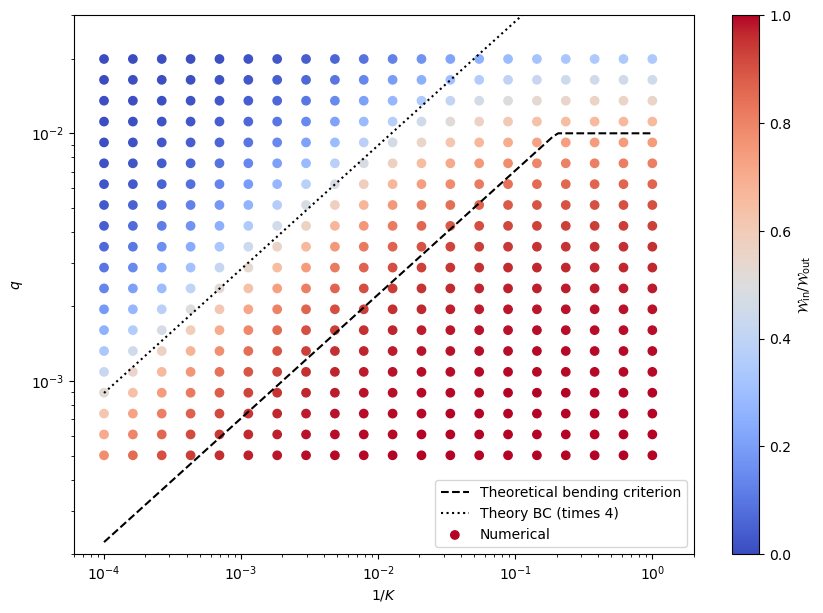

In [142]:
def plot_Wratios(q, K, Wratios):
    '''
    Plot W_in/W_out over the (q, K) parameter space.
    
    '''

    fig = plt.figure(figsize=(10,7))

    ## plot theoretical curve
    Sigma_gs = 10**np.linspace(-4, 0, 100)
    qs_pred = np.empty_like(Sigma_gs)
    qs_pred[(Sigma_gs > eps/Delta_g)] = cs*eps / a**2
    qs_pred[(Sigma_gs < eps/Delta_g)] = (Sigma_gs[(Sigma_gs < eps/Delta_g)] / (eps/Delta_g))**(1/2) * cs*eps/a**2
    plt.plot(Sigma_gs, qs_pred, color="black", ls="--", label="Theoretical bending criterion")
    plt.plot(Sigma_gs, 4*qs_pred, color="black", ls=":", label="Theory BC (times 4)")
    
    plt.scatter(1/Ks, qs, c=Wratios, vmin=0, vmax=1, cmap='coolwarm', label="Numerical")
    plt.xlabel(r"$1/K$")
    plt.ylabel(r"$q$")
    
    plt.xlim(6e-5, 2)
    plt.xscale('log')
    plt.ylim(2e-4, 3e-2)
    plt.yscale('log')
    
    plt.colorbar(label=r"$\mathcal{W}_\text{in}/\mathcal{W}_\text{out}$")
    
    #plt.scatter([],[], s=0, label="Rplus=" + str(Rplus))
    
    plt.legend(loc='lower right')
    
    save_fig = True
    if save_fig:
        plt.savefig("Figures/q_vs_K.png")
    plt.show()

plot_Wratios(qs, Ks, Wratios)

In [111]:
qs[0]

array([0.0005    , 0.00153571, 0.00257143, 0.00360714, 0.00464286,
       0.00567857, 0.00671429, 0.00775   , 0.00878571, 0.00982143,
       0.01085714, 0.01189286, 0.01292857, 0.01396429, 0.015     ])

In [106]:
compute_Win_div_Wout_vect(.015, 3)

array(0.50088908)